# <center> **Machine Learning for Social Data Science** <center/>

## <center> **Problem Set 2** <center/> 

### <center> *Solution 1 - all-MiniLM-L12-v2* <center/>

### **Topic Modelling**

#### **Load in Data**

In [2]:
import pandas as pd

COF = pd.read_csv("../Data/Levelling_Up_COF_Corpus.csv")

In [3]:
text = COF.Text.tolist()

#### **Embeddings**

In [4]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("all-MiniLM-L12-v2")

embeddings = embedding_model.encode(text)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


#### **Dimensionality Reduction with UMAP**

In [72]:
import umap

umap_model = umap.UMAP(n_neighbors = 5, n_components = 5, min_dist = 0.05, metric = "cosine", random_state = 42)

umap_embeddings = umap_model.fit_transform(embeddings)

#### **Clustering with HDBSCAN**

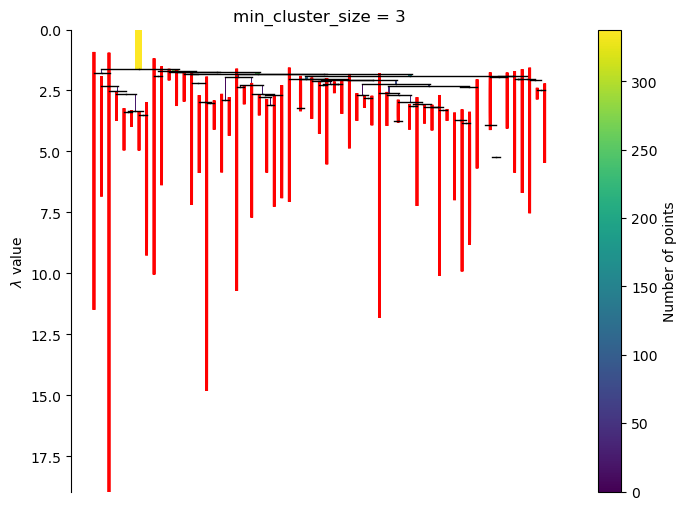

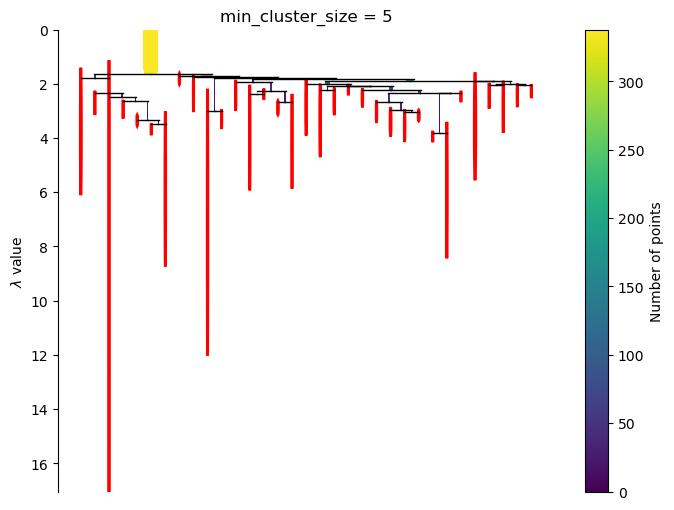

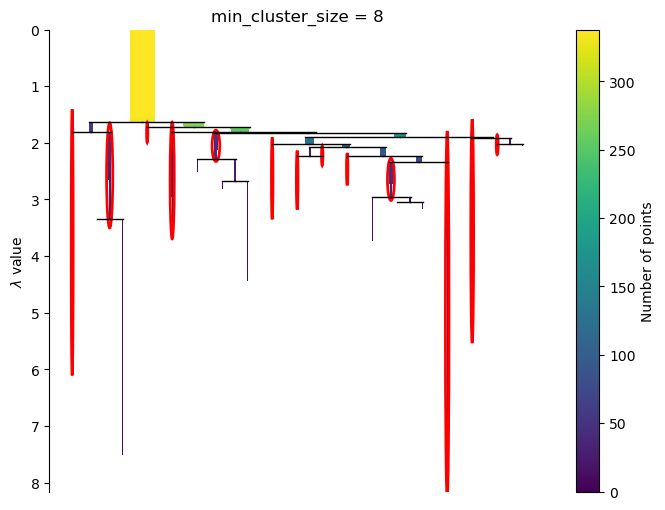

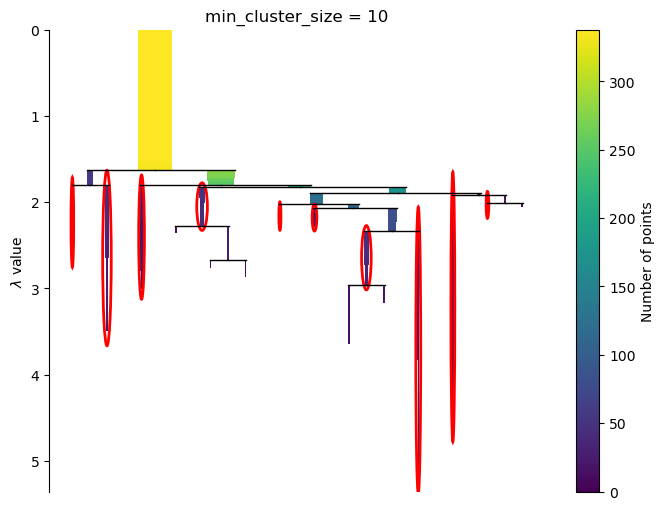

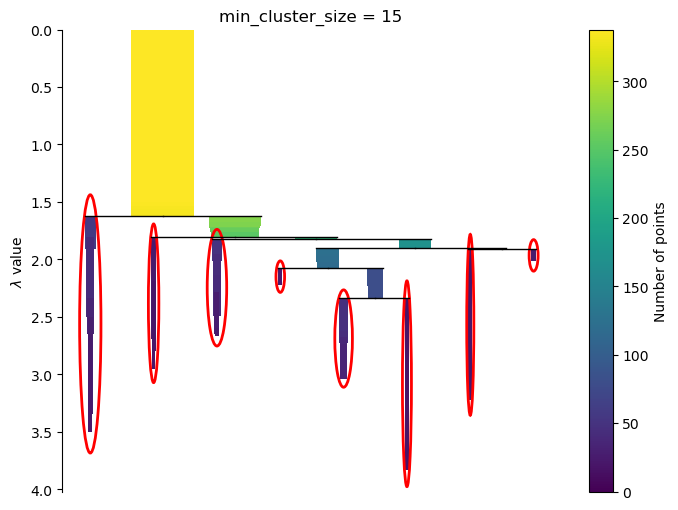

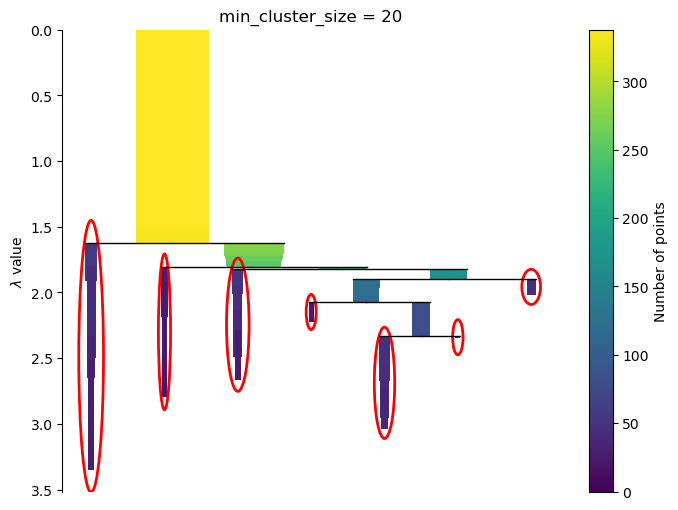

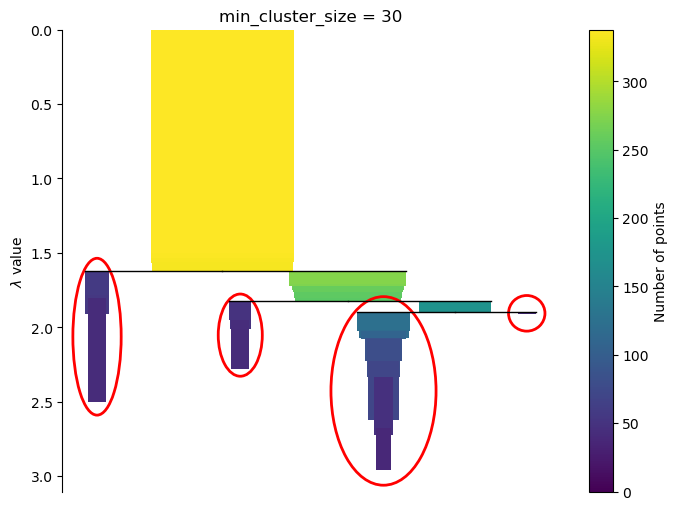

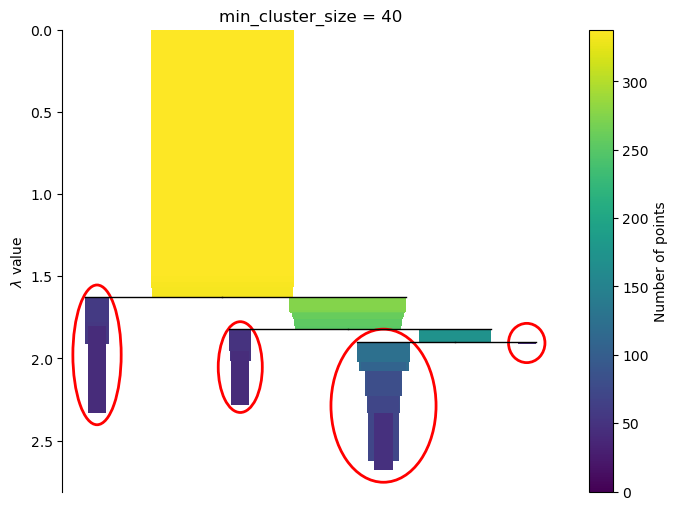

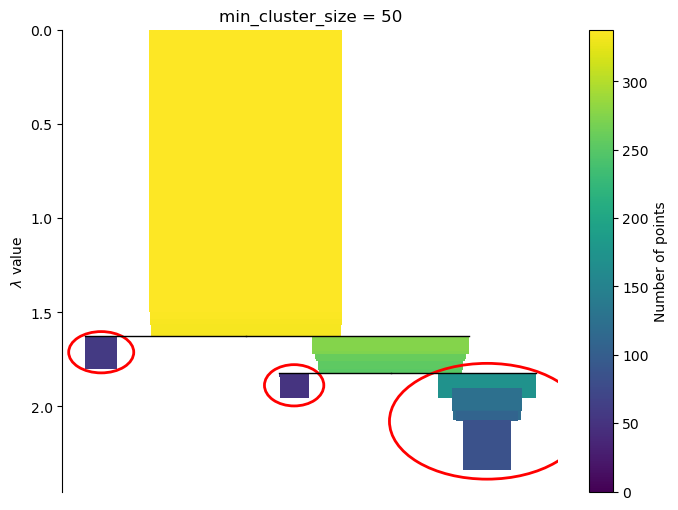

In [45]:
#Condensed Trees - Minimum Cluster Size
import os
import hdbscan
import matplotlib.pyplot as plt

save_folder = "../Raw Figures"
os.makedirs(save_folder, exist_ok = True)

min_cluster_sizes = [3, 5, 8, 10, 15, 20, 30, 40, 50]

for min_size in min_cluster_sizes:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size = min_size,
        min_samples = 1,
        metric = "euclidean",
        cluster_selection_method = "eom")
    clusterer.fit(umap_embeddings)
    plt.figure(figsize = (8, 6))
    clusterer.condensed_tree_.plot(select_clusters = True)
    plt.title(f"min_cluster_size = {min_size}")

#    plt.savefig(os.path.join(save_folder, f"Condensed_tree_cluster_{min_size}.png"))

plt.show()

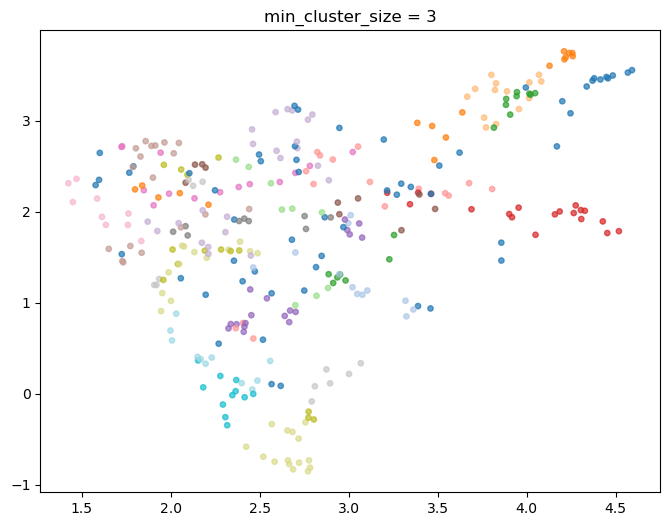

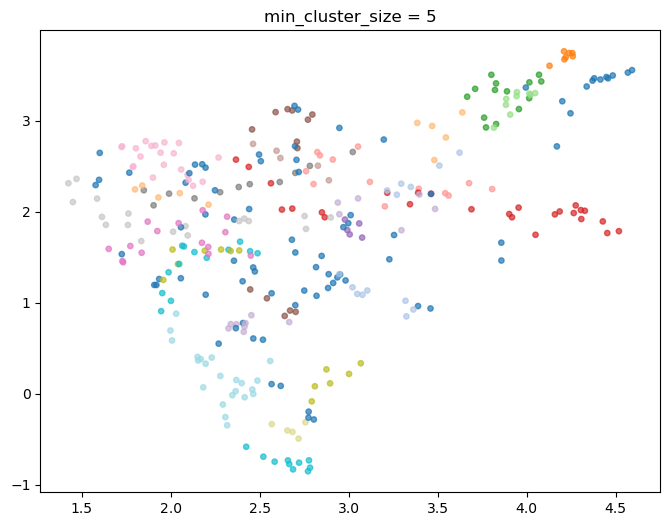

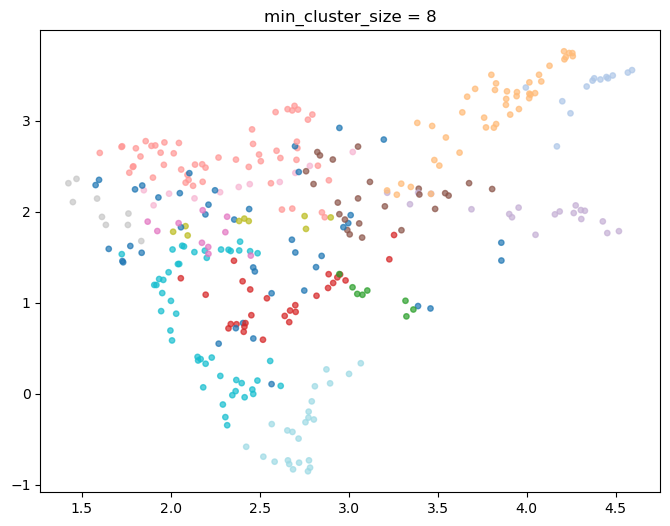

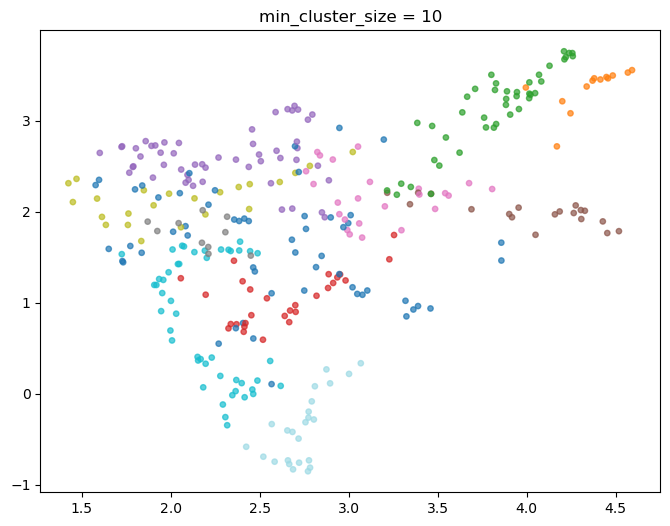

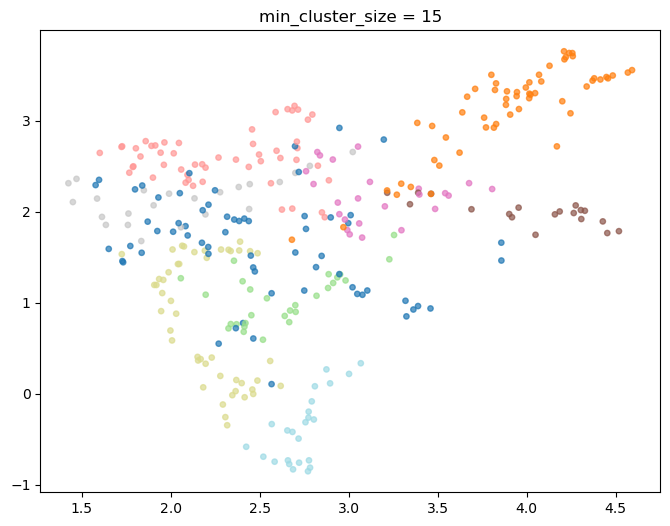

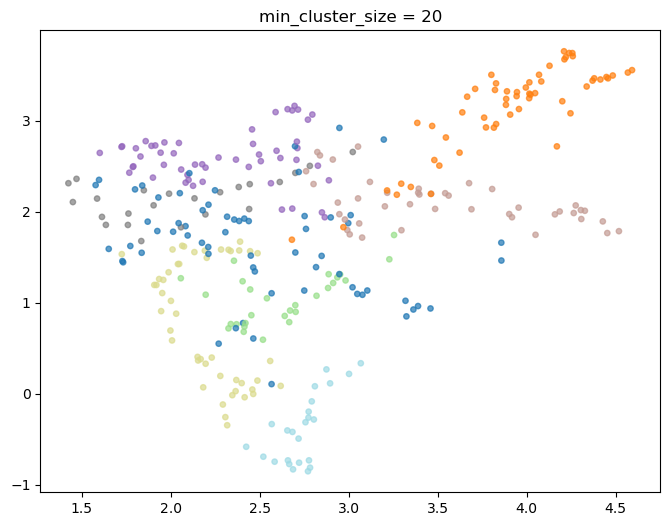

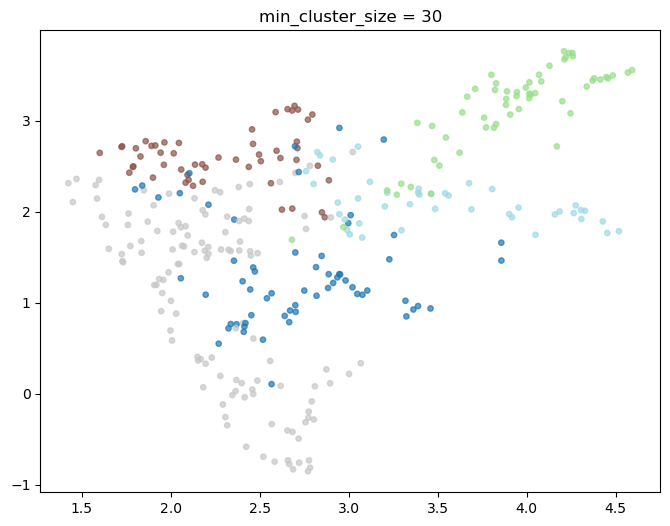

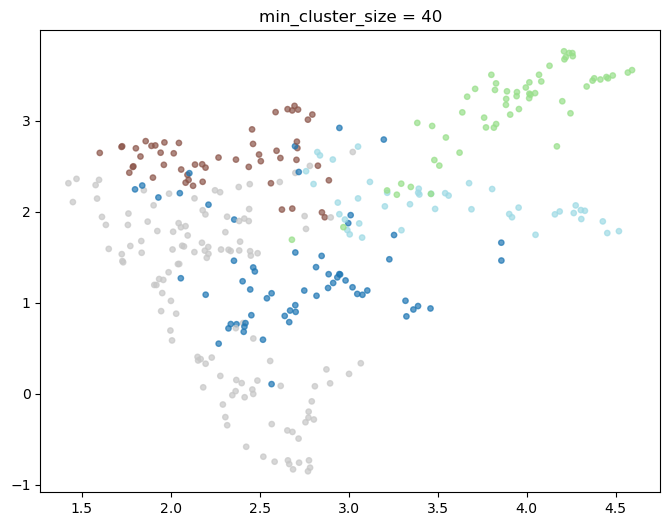

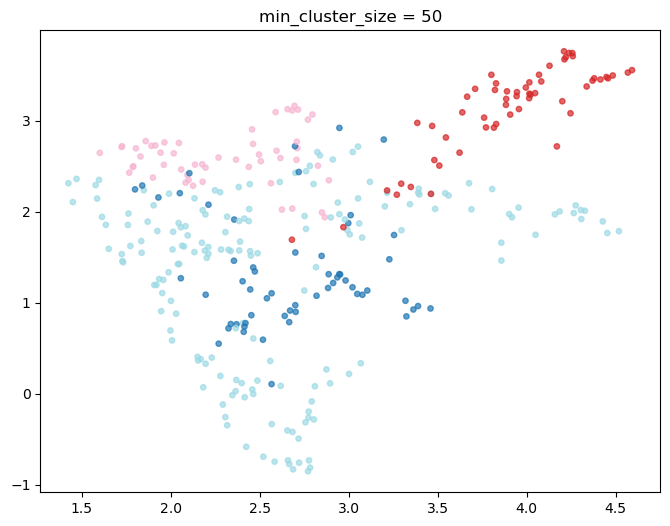

In [46]:
#Scatterplot - Minimum Cluster Size

for min_size in min_cluster_sizes:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size = min_size,
        min_samples = 1,
        metric = "euclidean",
        cluster_selection_method = "eom")
    clusterer.fit(umap_embeddings)
    labels = clusterer.labels_
    plt.figure(figsize = (8, 6))
    plt.scatter(
        umap_embeddings[:, 0],
        umap_embeddings[:, 1],
        c = labels,
        cmap = 'tab20',
        s = 15,
        alpha = 0.7)
    plt.title(f"min_cluster_size = {min_size}")
#    plt.savefig(os.path.join(save_folder, f"Scatter_plot_cluster_{min_size}.png"))

plt.show()

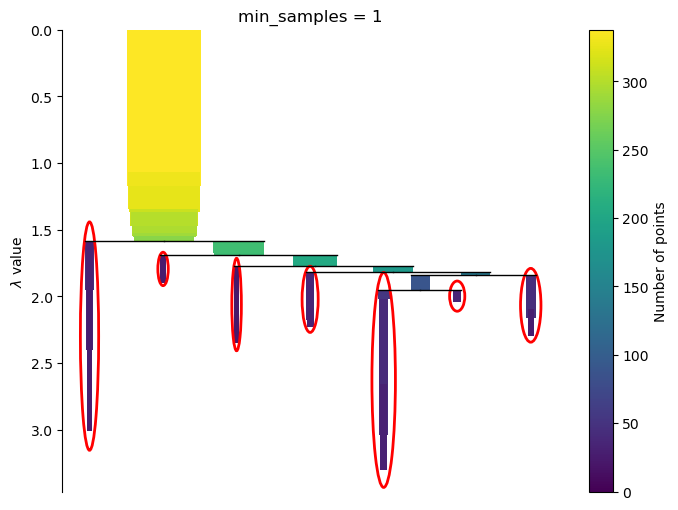

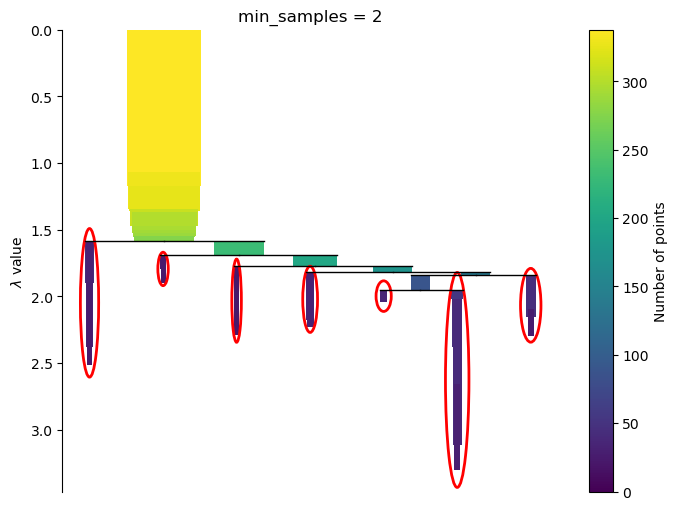

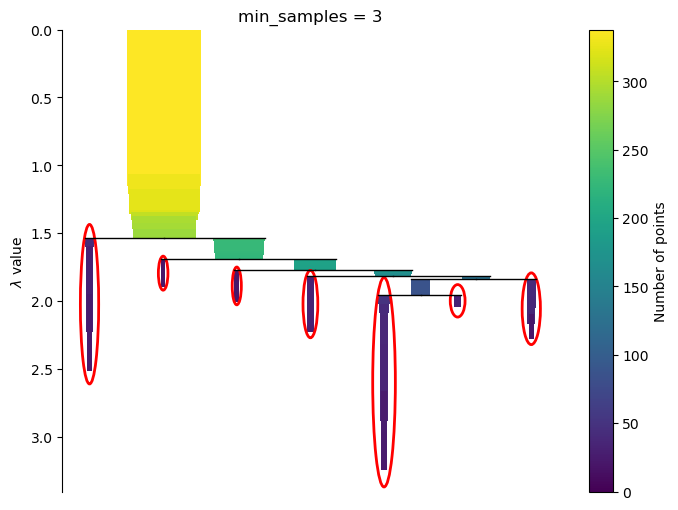

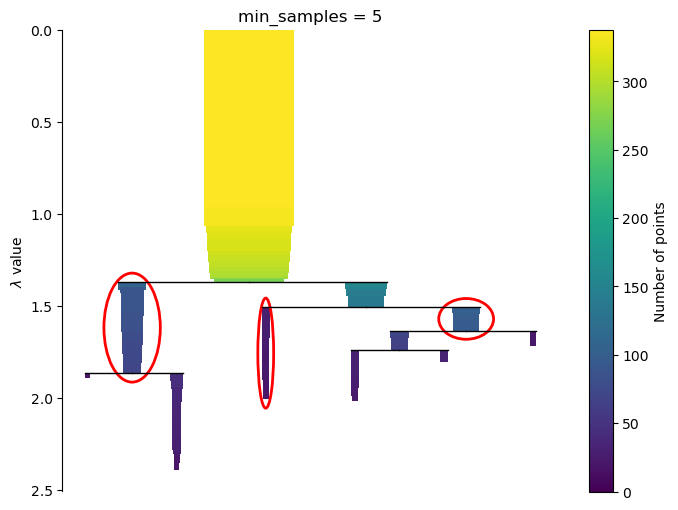

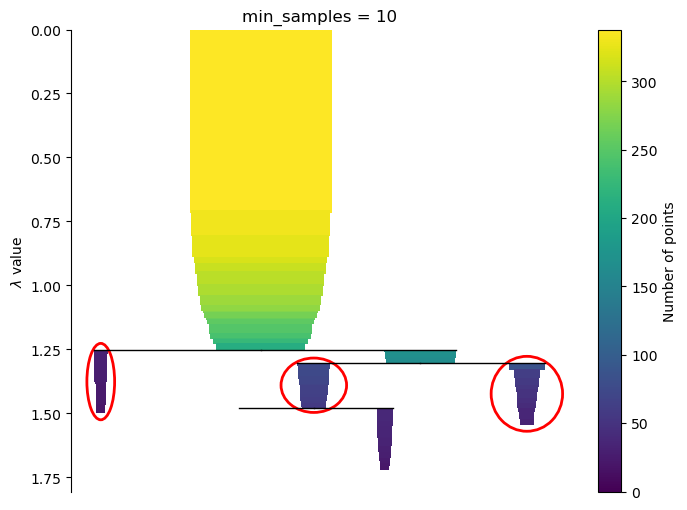

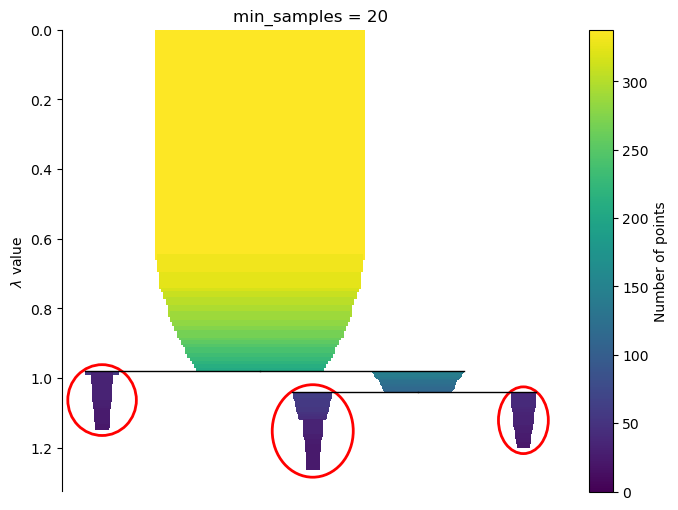

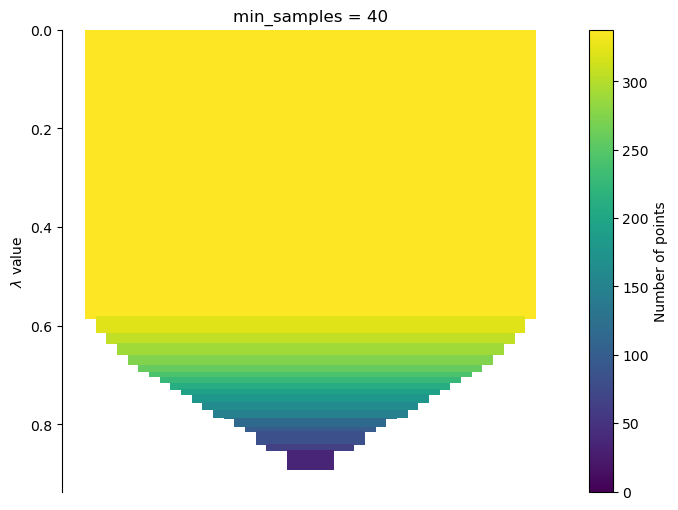

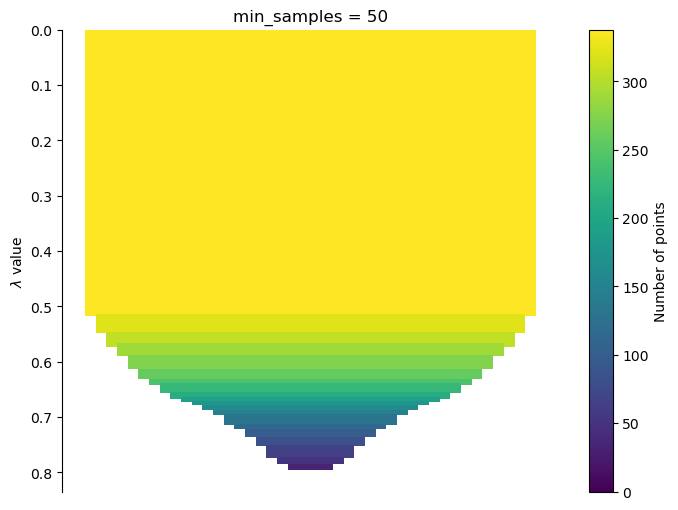

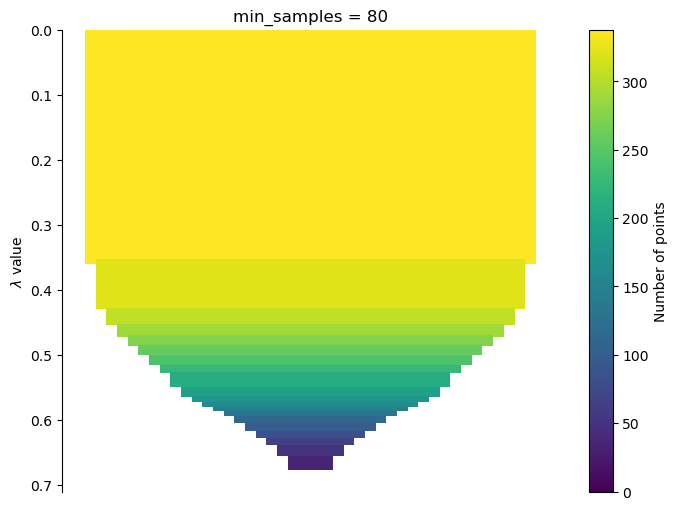

In [53]:
#Condensed Tree - Minimum Sample Size

min_sample_size = [1, 2, 3, 5, 10, 20, 40, 50, 80]

for min_size in min_sample_size:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size = 20,
        min_samples = min_size,
        metric = "euclidean",
        cluster_selection_method = "eom")
    clusterer.fit(umap_embeddings)
    plt.figure(figsize = (8, 6))
    clusterer.condensed_tree_.plot(select_clusters = True)
    plt.title(f"min_samples = {min_size}")
#    plt.savefig(os.path.join(save_folder, f"Condensed_tree_sample{min_size}.png"))

plt.show()

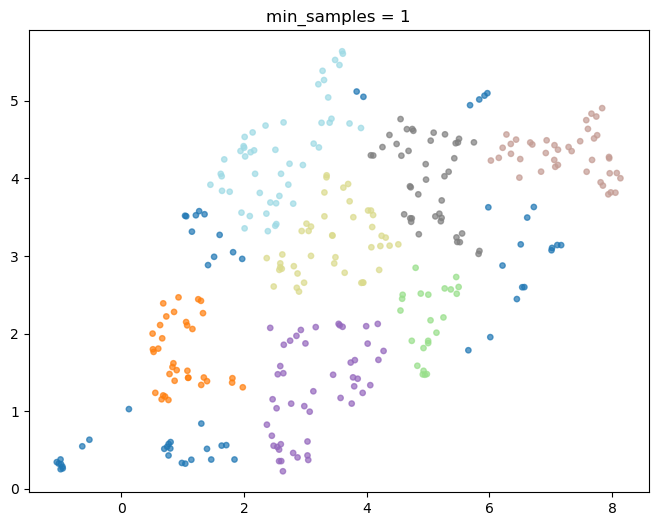

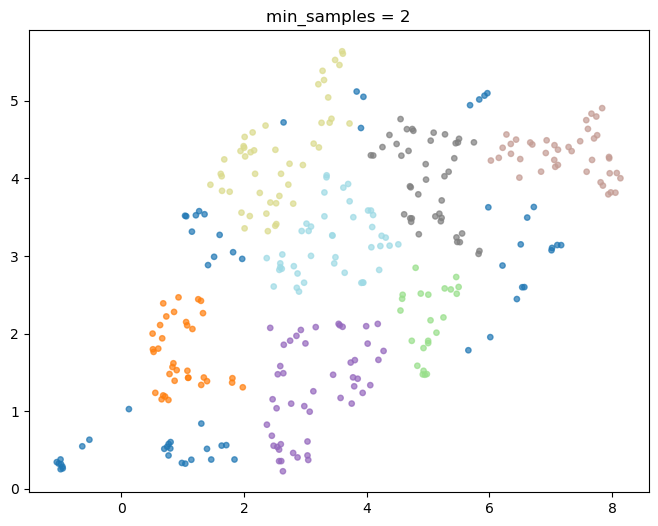

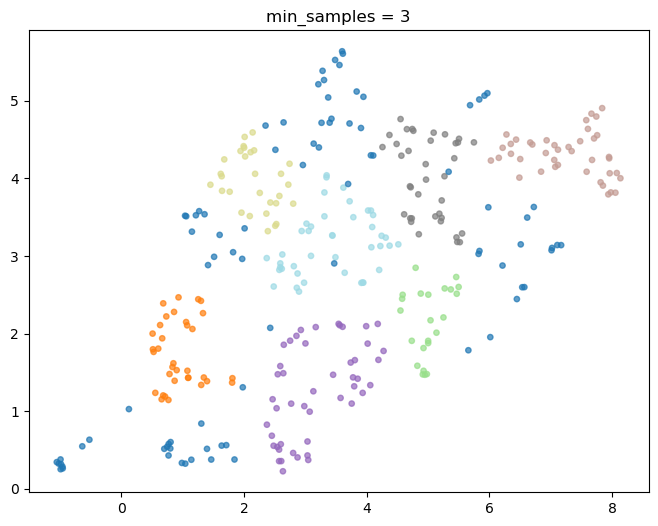

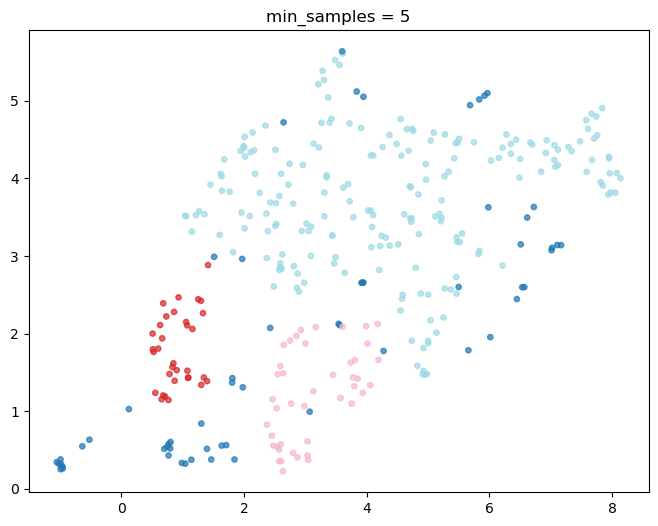

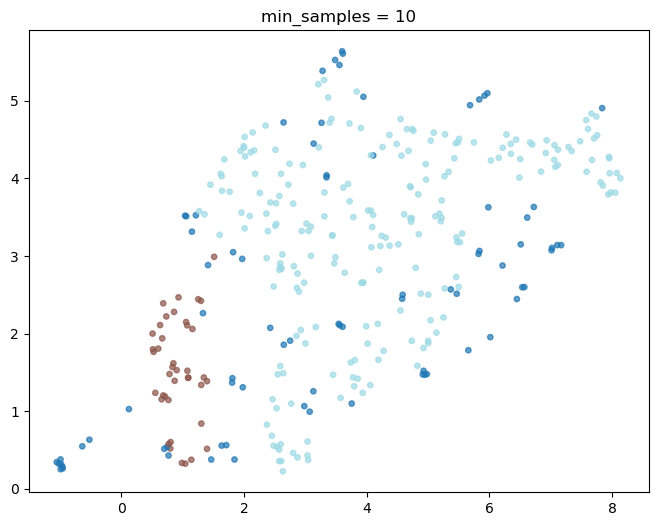

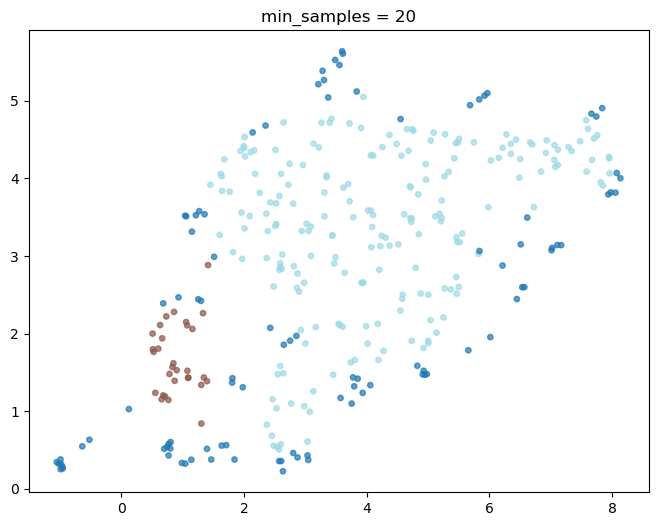

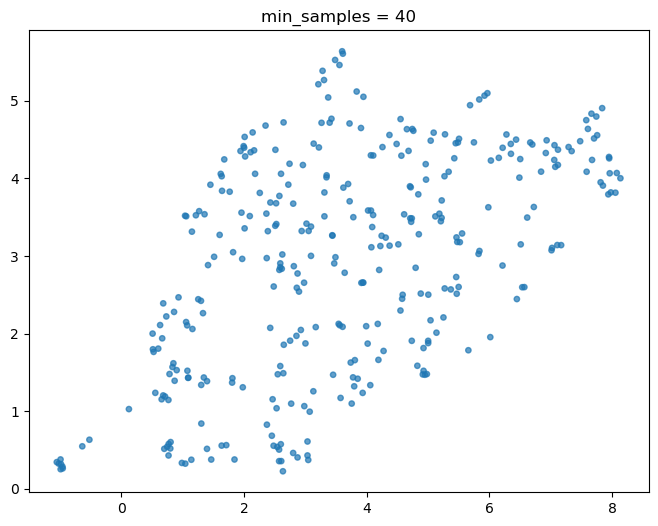

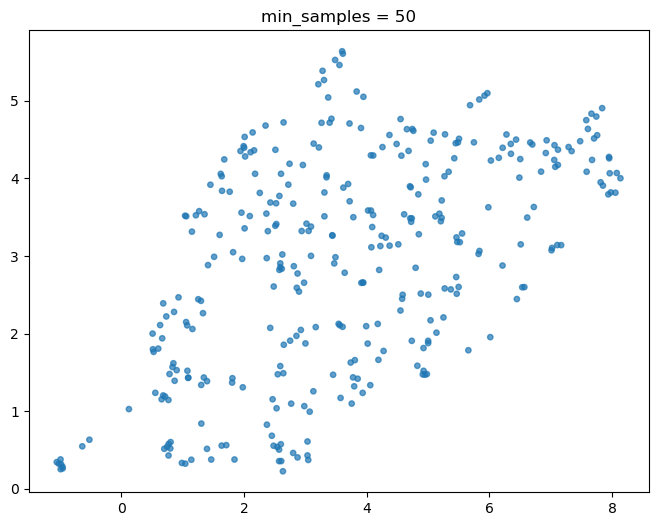

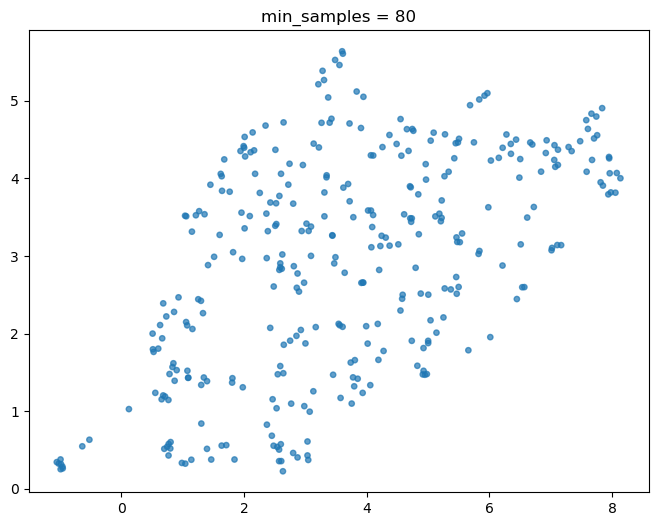

In [33]:
#Scatter plot - Minimum Sample Size

for min_size in min_sample_size:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size = 20,
        min_samples = min_size,
        metric = "euclidean",
        cluster_selection_method = "eom")
    clusterer.fit(umap_embeddings)
    labels = clusterer.labels_
    plt.figure(figsize = (8, 6))
    plt.scatter(
        umap_embeddings[:, 0],
        umap_embeddings[:, 1],
        c = labels,
        cmap = 'tab20',
        s = 15,
        alpha = 0.7)
    plt.title(f"min_samples = {min_size}")
#    plt.savefig(os.path.join(save_folder, f"scatter_plot_sample_{min_size}.png"))

plt.show()

In [64]:
#Final Model

clustering_model = hdbscan.HDBSCAN(min_cluster_size = 20, 
                                min_samples = 3,
                                metric = "euclidean",
                                cluster_selection_method = "eom") 

#### **Vectorisation**

In [59]:
from sklearn.feature_extraction.text import CountVectorizer

vectoriser_model = CountVectorizer(ngram_range = (1, 2), min_df = 0.01, max_df = 0.8, stop_words = 'english')

#### **Representation**

In [60]:
from bertopic.representation import KeyBERTInspired

representation_model = KeyBERTInspired()

#### **BERTopic**

In [73]:
#Run Model
from bertopic import BERTopic

topic_model = BERTopic(
    embedding_model = embedding_model,
    umap_model = umap_model,
    hdbscan_model = clustering_model,
    vectorizer_model = vectoriser_model,
    representation_model = representation_model)

topics, probabilities = topic_model.fit_transform(text)

topic_info = topic_model.get_topic_info()

print(topic_info)

   Topic  Count                                               Name  \
0     -1     91  -1_northumberland_community shop_town deal_mar...   
1      0     52  0_community pavilion_new clubhouse_leisure cen...   
2      1     42     1_abbey_stretford public_public hall_rock hall   
3      2     42  2_george community_hastings commons_community ...   
4      3     34        3_marple wharf_wharf marple_wharf_town hall   
5      4     34  4_town hall_visitor centre_projects scotland_s...   
6      5     22  5_village hall_town hall_hall community_hall b...   
7      6     21  6_kingswood house_auditorium_granville hotel_a...   

                                      Representation  \
0  [northumberland, community shop, town deal, ma...   
1  [community pavilion, new clubhouse, leisure ce...   
2  [abbey, stretford public, public hall, rock ha...   
3  [george community, hastings commons, community...   
4  [marple wharf, wharf marple, wharf, town hall,...   
5  [town hall, visitor centre, pr

In [74]:
topic_model.visualize_barchart()

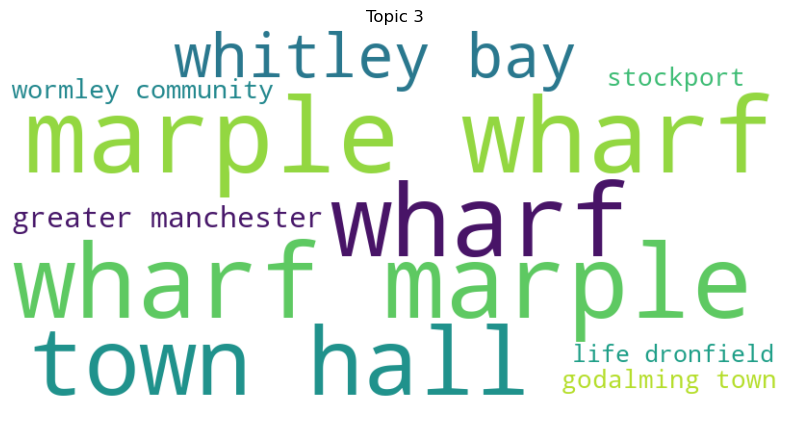

In [82]:
from wordcloud import WordCloud

topic_id = 3
word_probs = {word: prob for word, prob in topic_model.get_topic(topic_id)}

wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      prefer_horizontal=1.0).generate_from_frequencies(word_probs)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(f'Topic {topic_id}')
plt.show()

In [81]:
topic_model.visualize_topics()

### **Validation**